In [1]:
from boututils.datafile import DataFile
from boutdata.collect import collect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys, pathlib
import platform
import traceback
import xarray as xr
import xbout
from pathlib import Path
import xhermes as xh

sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/sdtool_load_test/sdtools"))
sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/analysis/my_notebooks/notebooks/hermes-3/transients"))
sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/analysis/my_notebooks/notebooks/hermes-3/general_functions"))


from plotting_functions import *
from convergence_functions import * 
from sparc_funcs import *

from hermes3.case_db import *
from hermes3.casedeck import*
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *
from hermes3.fluxes import *
from hermes3.selectors import *
from hermes3.front_tracking import *
# from hermes3.balance1d import *

# plt.style.use('ggplot')
plt.rcParams.update({'font.size': 10})
linewidth = 3
markersize = 15



# plt.style.use('ggplot')
plt.style.use('default')
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['axes.grid'] = True
plt.rcParams.update({'font.size': 16})



%load_ext autoreload
%autoreload 2


# I/O

In [2]:
parent_dir = '/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2025-06_glimmer_scenario_development/pulses/300%_fluence/flux_limited/runs'

names = ['fcx_off', 'fcx_off_case_2', 'fcx_on']
cs = dict()

# cs['fcx_off'] = Load.case_1D('/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2025-06_glimmer_scenario_development/pulses/300%_fluence/flux_limited/runs/fcx_off', guard_replace=False, use_squash=True)

for name in names:
    path = f'{parent_dir}/{name}'
    print(f'Loading case: {name} from {path}')
    cs[name] = Load.case_1D(path,guard_replace = False, use_squash=True)
    

Loading case: fcx_off from /users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2025-06_glimmer_scenario_development/pulses/300%_fluence/flux_limited/runs/fcx_off
- Looking for squash file
- Squash file found. squash date 07/17/2025, 13:36:30, dmp file date 07/16/2025, 23:05:26
Skipping unnormalisation
Loading case: fcx_off_case_2 from /users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2025-06_glimmer_scenario_development/pulses/300%_fluence/flux_limited/runs/fcx_off_case_2
- Looking for squash file
- Squash file found. squash date 07/17/2025, 13:36:56, dmp file date 07/16/2025, 23:37:06
Skipping unnormalisation
Loading case: fcx_on from /users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2025-06_glimmer_scenario_development/pulses/300%_fluence/flux_limited/runs/fcx_on
- Looking for squash file
- Squash file found. squash date 07/17/2025, 13:37:31, dmp file date 07/17/2025, 04:01:40
Skipping unnormalisation


In [3]:
cs['fcx_off'].ds.data_vars

Data variables:
    Bxy                      (pos) float64 dask.array<chunksize=(404,), meta=np.ndarray>
    Ed+_iz                   (t, pos) float64 dask.array<chunksize=(3011, 404), meta=np.ndarray>
    Ed+_rec                  (t, pos) float64 dask.array<chunksize=(3011, 404), meta=np.ndarray>
    Ed_target_recycle        (t, pos) float64 dask.array<chunksize=(3011, 404), meta=np.ndarray>
    Edd+_cx                  (t, pos) float64 dask.array<chunksize=(3011, 404), meta=np.ndarray>
    Fd+_iz                   (t, pos) float64 dask.array<chunksize=(3011, 404), meta=np.ndarray>
    Fd+_rec                  (t, pos) float64 dask.array<chunksize=(3011, 404), meta=np.ndarray>
    Fdd+_cx                  (t, pos) float64 dask.array<chunksize=(3011, 404), meta=np.ndarray>
    G1                       (pos) float64 dask.array<chunksize=(404,), meta=np.ndarray>
    G2                       (pos) float64 dask.array<chunksize=(404,), meta=np.ndarray>
    G3                       (pos) flo

In [4]:
print(cs['fcx_off'].ds['Ed+_iz'])

<xarray.DataArray 'Ed+_iz' (t: 3011, pos: 404)>
dask.array<getitem, shape=(3011, 404), dtype=float64, chunksize=(3011, 404), chunktype=numpy.ndarray>
Coordinates:
    dx       (pos) float64 dask.array<chunksize=(404,), meta=np.ndarray>
    dy       (pos) float64 dask.array<chunksize=(404,), meta=np.ndarray>
    dz       (pos) float64 dask.array<chunksize=(404,), meta=np.ndarray>
  * t        (t) float64 1.748 1.749 1.75 1.751 ... 1.788 1.788 1.788 1.788
    y        (pos) float64 0.2193 0.6573 1.094 1.53 ... 92.84 92.86 92.89 92.91
  * pos      (pos) float64 -0.6565 -0.2185 0.2185 0.6545 ... 91.99 92.01 92.03
Attributes:
    current_time_index:  3011
    cell_location:       CELL_CENTRE
    conversion:          15346982899.153515
    direction_y:         Standard
    direction_z:         Standard
    long_name:           Energy transfer due to ionisation of d to d+
    source:              amjuel_hyd_ionisation
    standard_name:       energy transfer
    time_dimension:      t
    uni

In [5]:

def replace_guards(var):
    """
    This in-place replaces the points in the guard cells with the points 
    on the boundary.
    """
    var = var[1:-1]  # Strip the edge guard cells

    var[0] = 0.5 * (var[0] + var[1])
    var[-1] = 0.5 * (var[-1] + var[-2])
    
    return var

# Profiles

Loaded case: fcx_off_case_2 with 96 data variables
Loaded case: fcx_on with 96 data variables


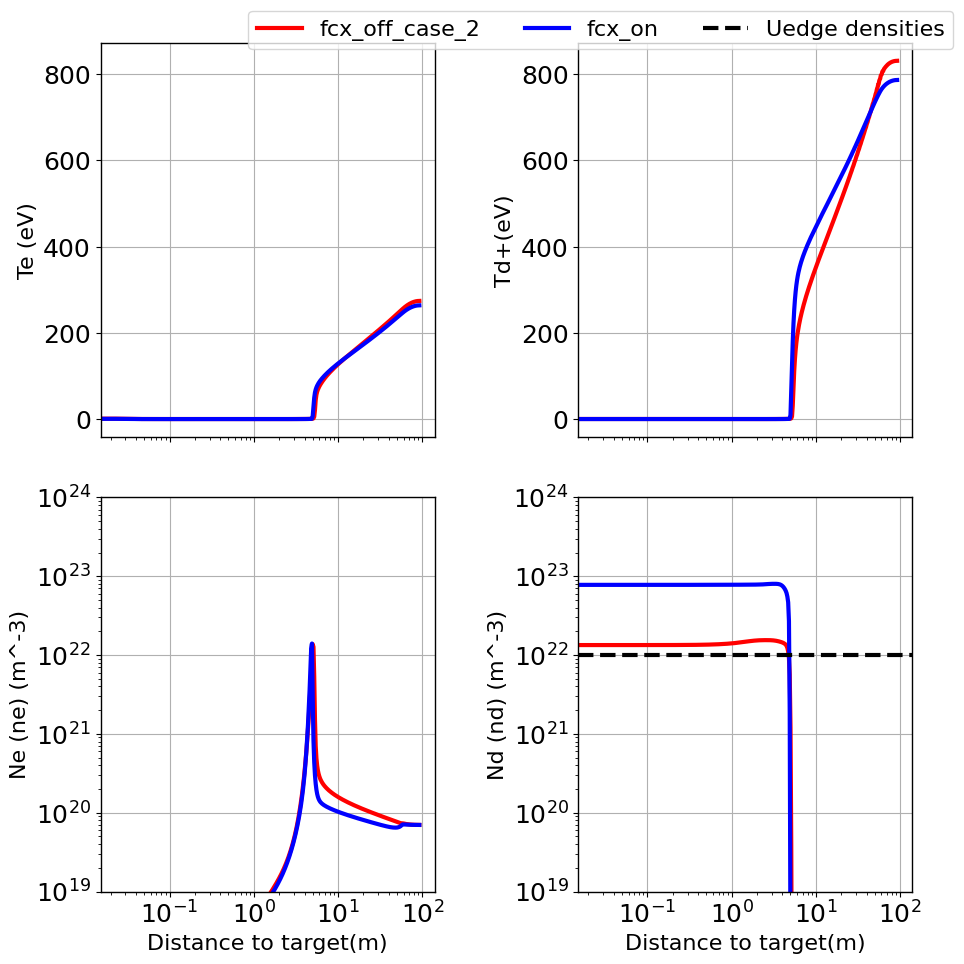

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10), sharex=True)

# Share y-axes within each row
ax[0, 1].sharey(ax[0, 0])  # Top row: ax[1] shares y with ax[0]
ax[1, 1].sharey(ax[1, 0])  # Bottom row: ax[3] shares y with ax[2]

ax = ax.flatten()

for name, c in cs.items():

    if name != 'fcx_off':
        print(f'Loaded case: {name} with {len(cs[name].ds.data_vars)} data variables')

        if name == 'fcx_off_case_2':
            color = 'red'
        elif name == 'fcx_on':
            color = 'blue'

        Te = replace_guards(c.ds['Te'].isel(t=0))
        Ti = replace_guards(c.ds['Td+'].isel(t=0))
        ne = replace_guards(c.ds['Ne'].isel(t=0))
        nd = replace_guards(c.ds['Nd'].isel(t=0))
        y = c.ds['pos'][1:-1]
        y_flipped = y.max()- y 

        ax[0].plot(y_flipped, Te, label = f'{name}',  linewidth=linewidth, color=color)
        ax[1].plot(y_flipped, Ti,  linewidth=linewidth, color=color)
        ax[2].plot(y_flipped, ne,  linewidth=linewidth, color=color)
        ax[3].plot(y_flipped, nd, linewidth=linewidth, color = color)

ax[3].axhline(1e22, color='black', linestyle='--', label='Uedge densities', linewidth=linewidth)

ax[0].set_ylabel(f'Te ({c.ds["Te"].units})')
ax[1].set_ylabel(f'Td+({c.ds["Td+"].units})')
ax[2].set_ylabel(f'Ne (ne) ({c.ds["Ne"].units})')
ax[3].set_ylabel(f'Nd (nd) ({c.ds["Nd"].units})')
ax[3].set_xlabel('Distance to target(m)')
ax[2].set_xlabel('Distance to target(m)')

ax[2].set_yscale('log')
ax[3].set_yscale('log')
ax[3].set_ylim(1e19, 1e24)

ax[3].set_xscale('log')
plt.tight_layout(pad=2.0)
fig.legend(ncol=3)

In [7]:
fig, ax = plt.subplots(1,3, figsize=(10, 6))
ax = ax.flatten()
for name in names:
    print(f'Loaded case: {name} with {len(cs[name].ds.data_vars)} data variables')
    
    if name != 'fcx_off':
    
    
    




SyntaxError: incomplete input (2314671100.py, line 11)

Plotting time series for fcx_off


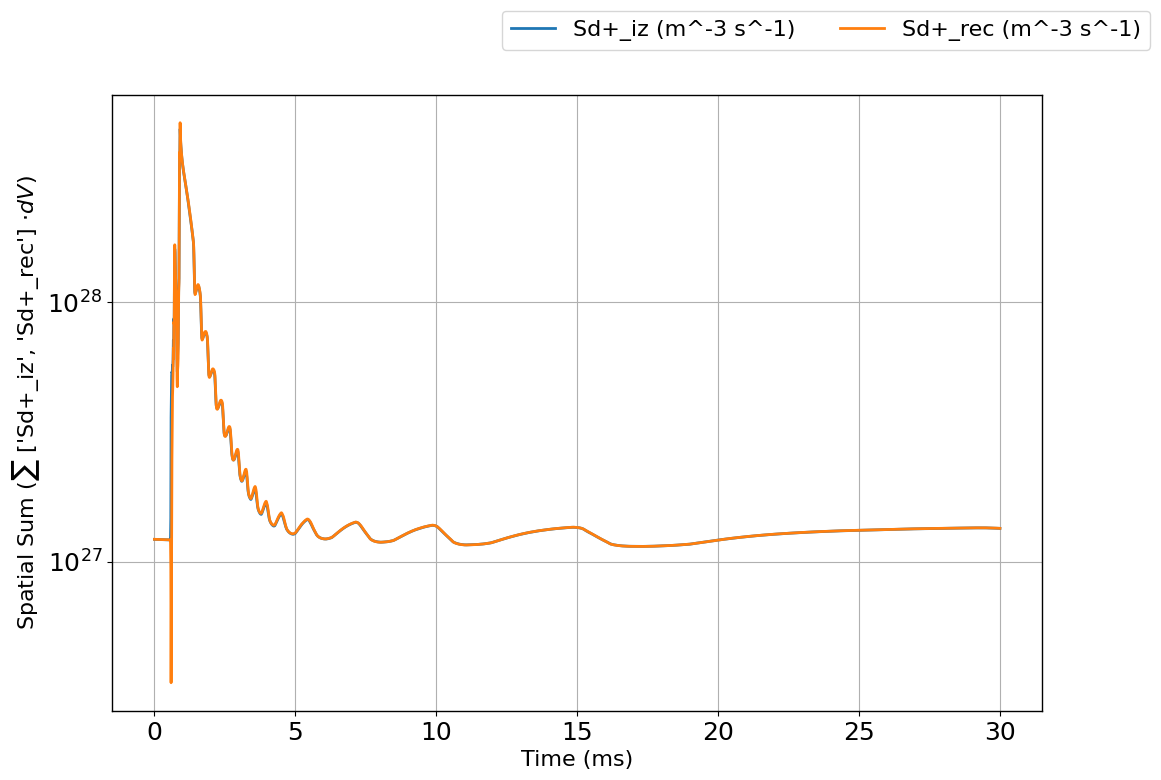

Plotting time series for fcx_off_case_2


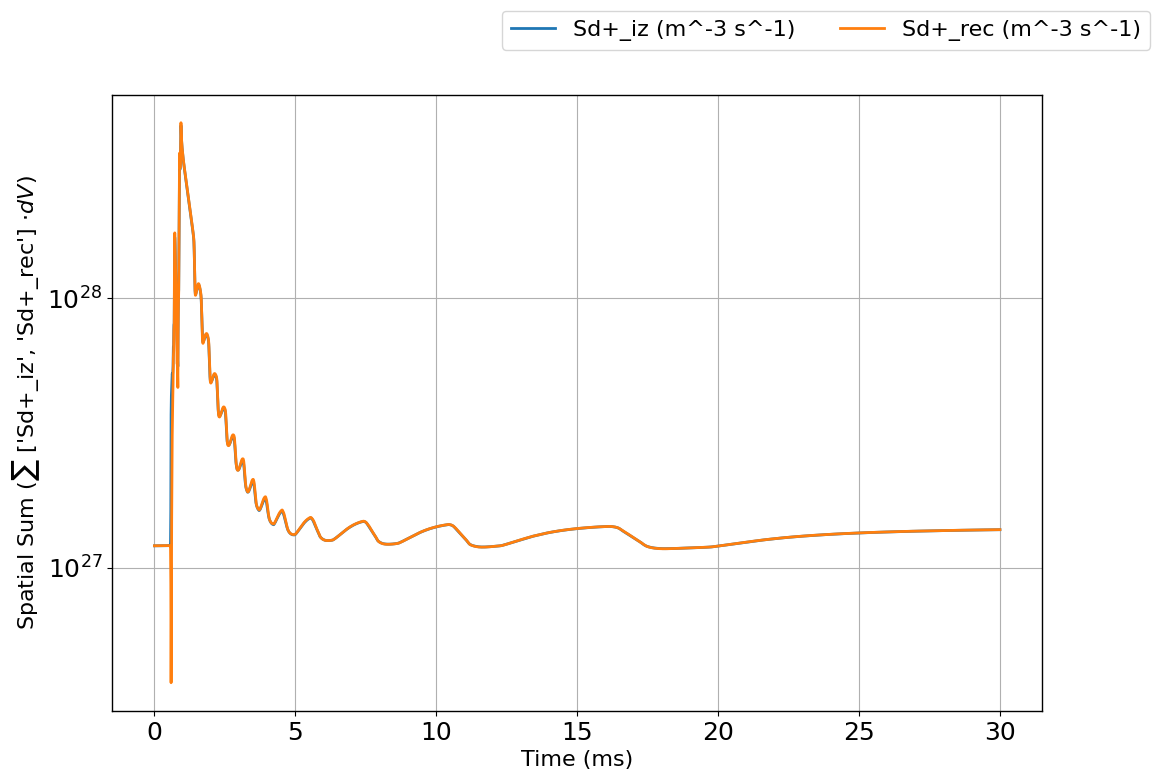

Plotting time series for fcx_on


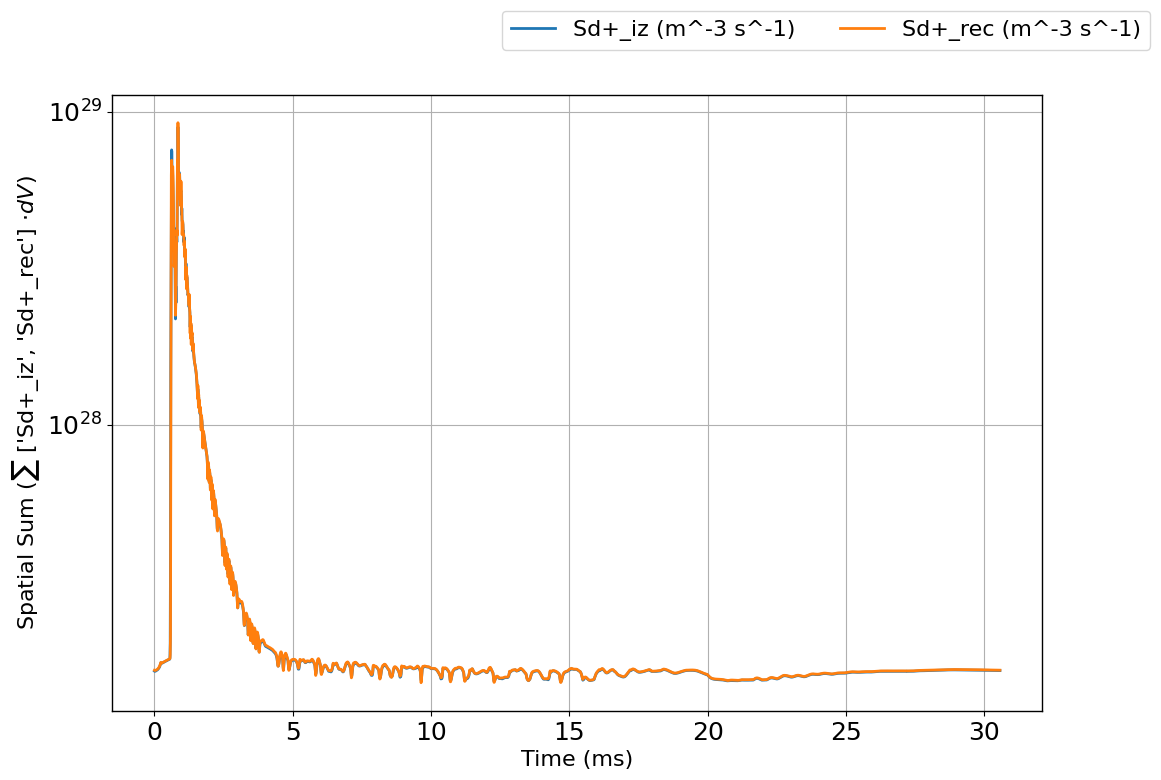

In [ ]:

sources_sinks = ['Sd+_iz', 'Sd+_rec']


for name, c in cs.items():
    print(f'Plotting time series for {name}')
    plot_spatial_sum_time_series(cs[name], vars = sources_sinks, time_range=(10, -1), mult_dv=True, y_scale='symlog', abs = True)


Plotting time series for fcx_off


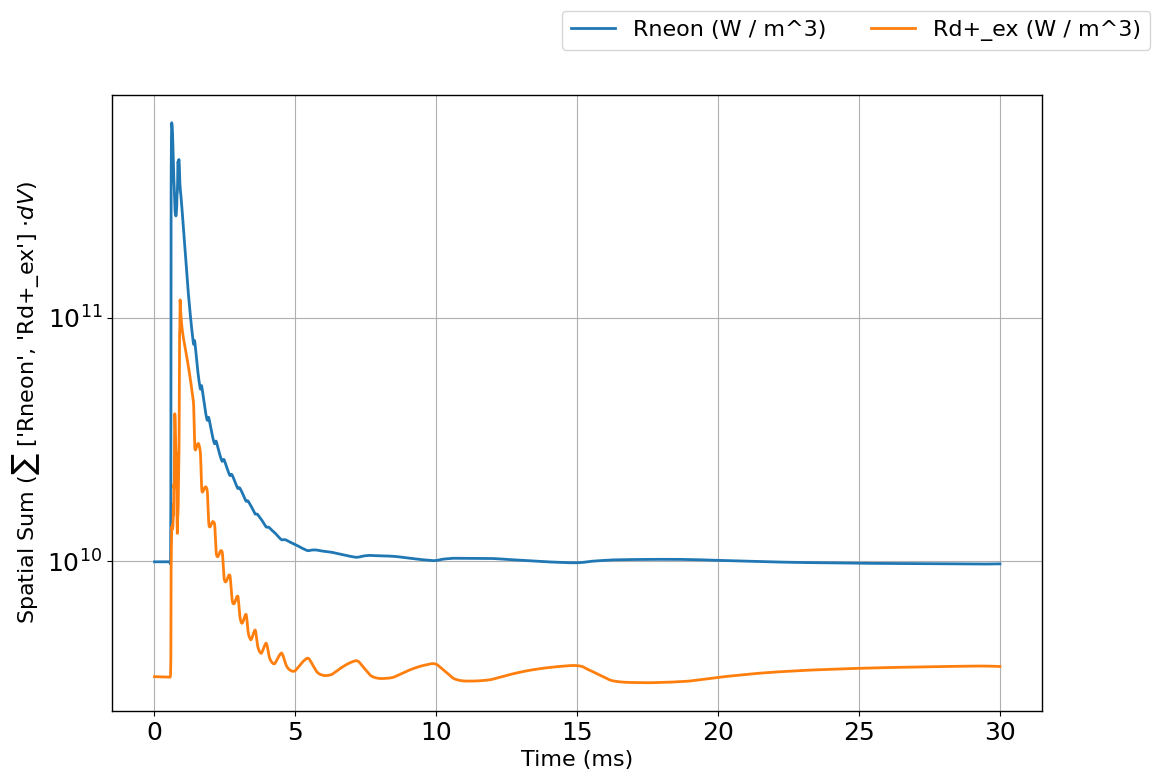

Plotting time series for fcx_off_case_2


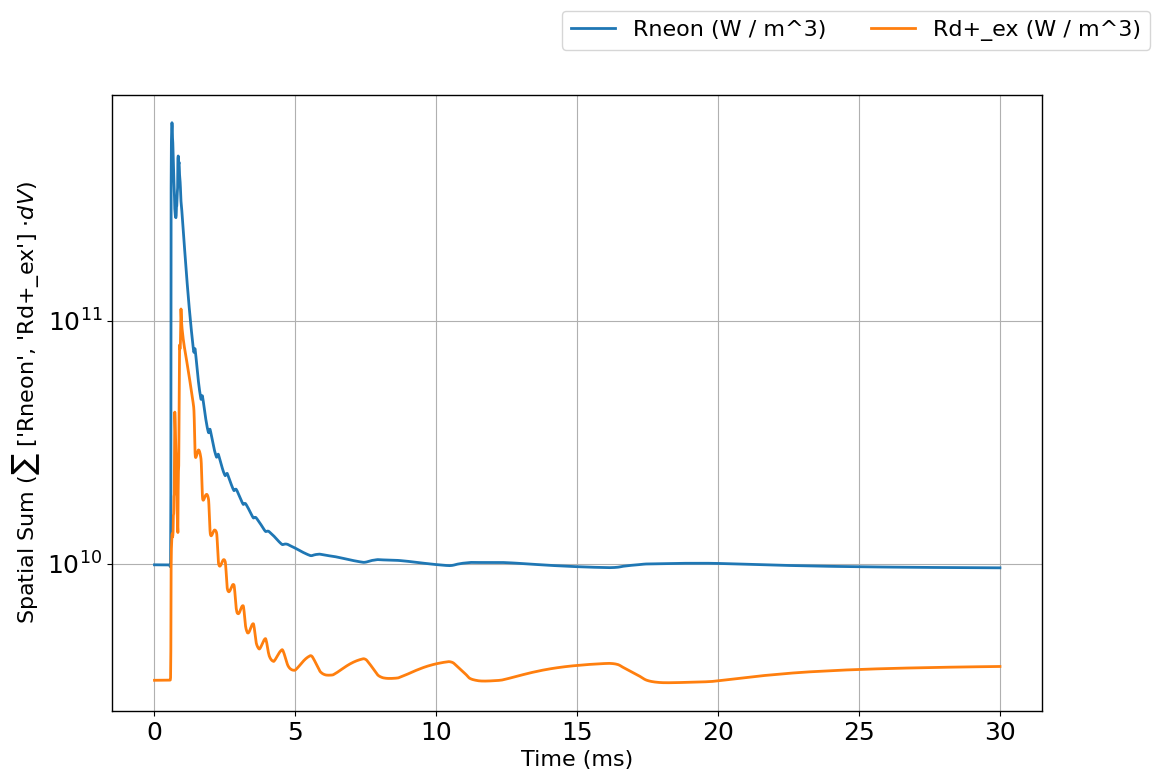

Plotting time series for fcx_on


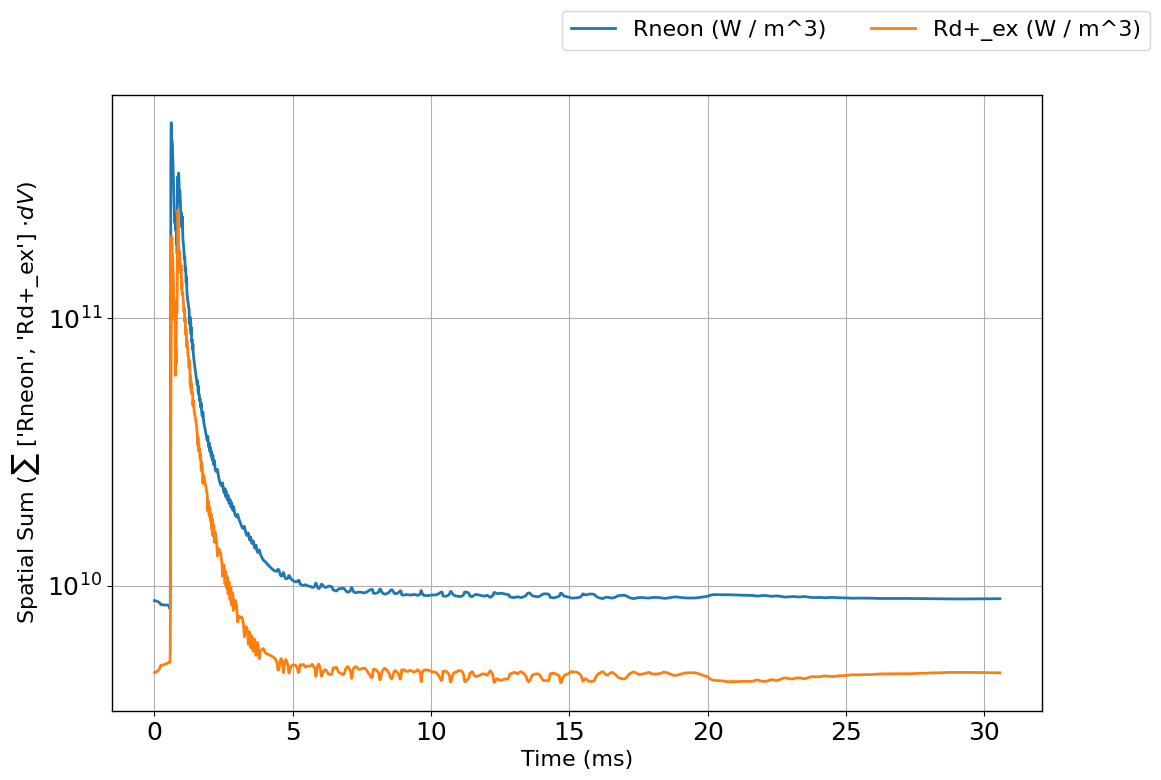

In [ ]:

sources_sinks = ['Rneon', 'Rd+_ex']


for name, c in cs.items():
    print(f'Plotting time series for {name}')
    plot_spatial_sum_time_series(cs[name], vars = sources_sinks, time_range=(10, -1), mult_dv=True, y_scale='symlog', abs = True)


# Sources and sinks

Plotting time series for fcx_off_case_2


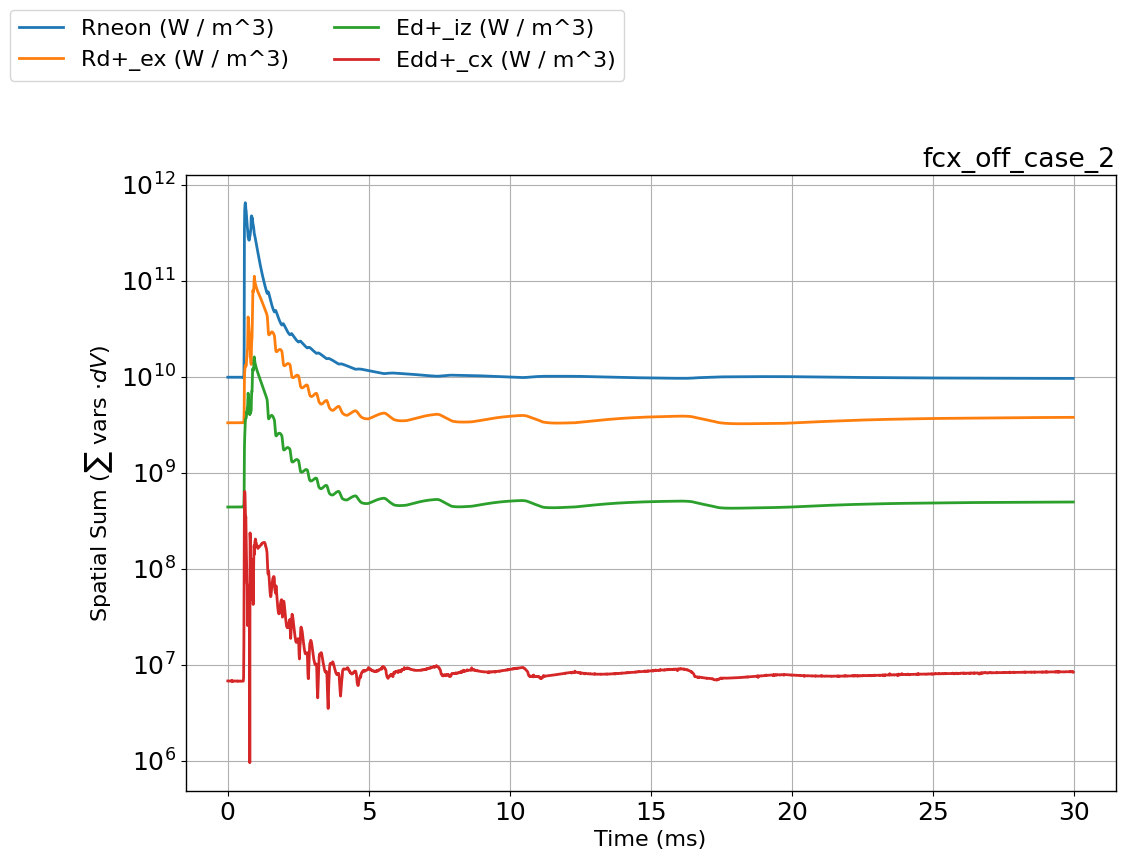

Plotting time series for fcx_on


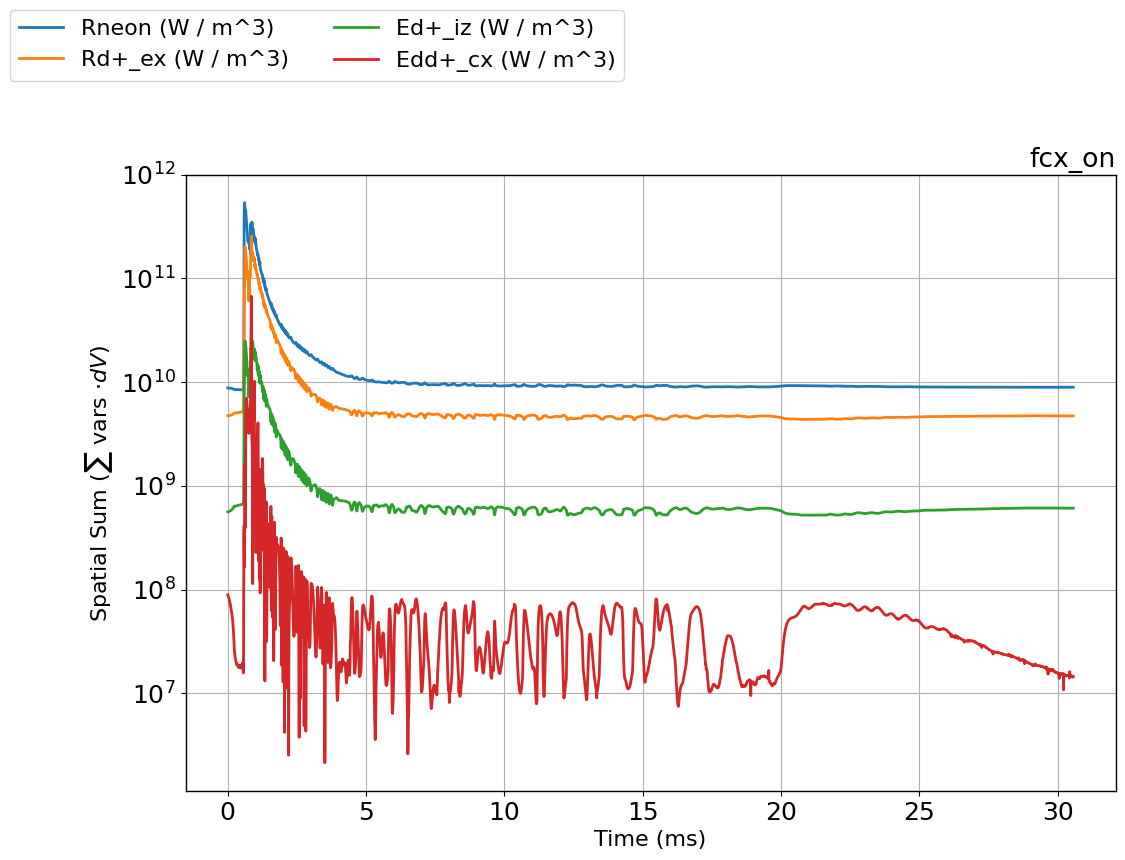

In [8]:


for name, c in cs.items():
    if name == 'fcx_off':
        continue
    print(f'Plotting time series for {name}')
    plot_spatial_sum_time_series(c, vars = ['Rneon', 'Rd+_ex', 'Ed+_iz', 'Edd+_cx'], 
                                 time_range=(10, -1), mult_dv=True, y_scale='symlog', abs = True, title=name)
# sources_sinks = ['Sd+_iz', 'Sd+_rec','Sd+_sheath','Sd_target_recycle', 'simple_pump_sink_d']

# plot_spatial_sum_time_series(cs['power_and_density'], vars = sources_sinks, time_range=(0, 200), mult_dv=True, y_scale='symlog', abs = False)

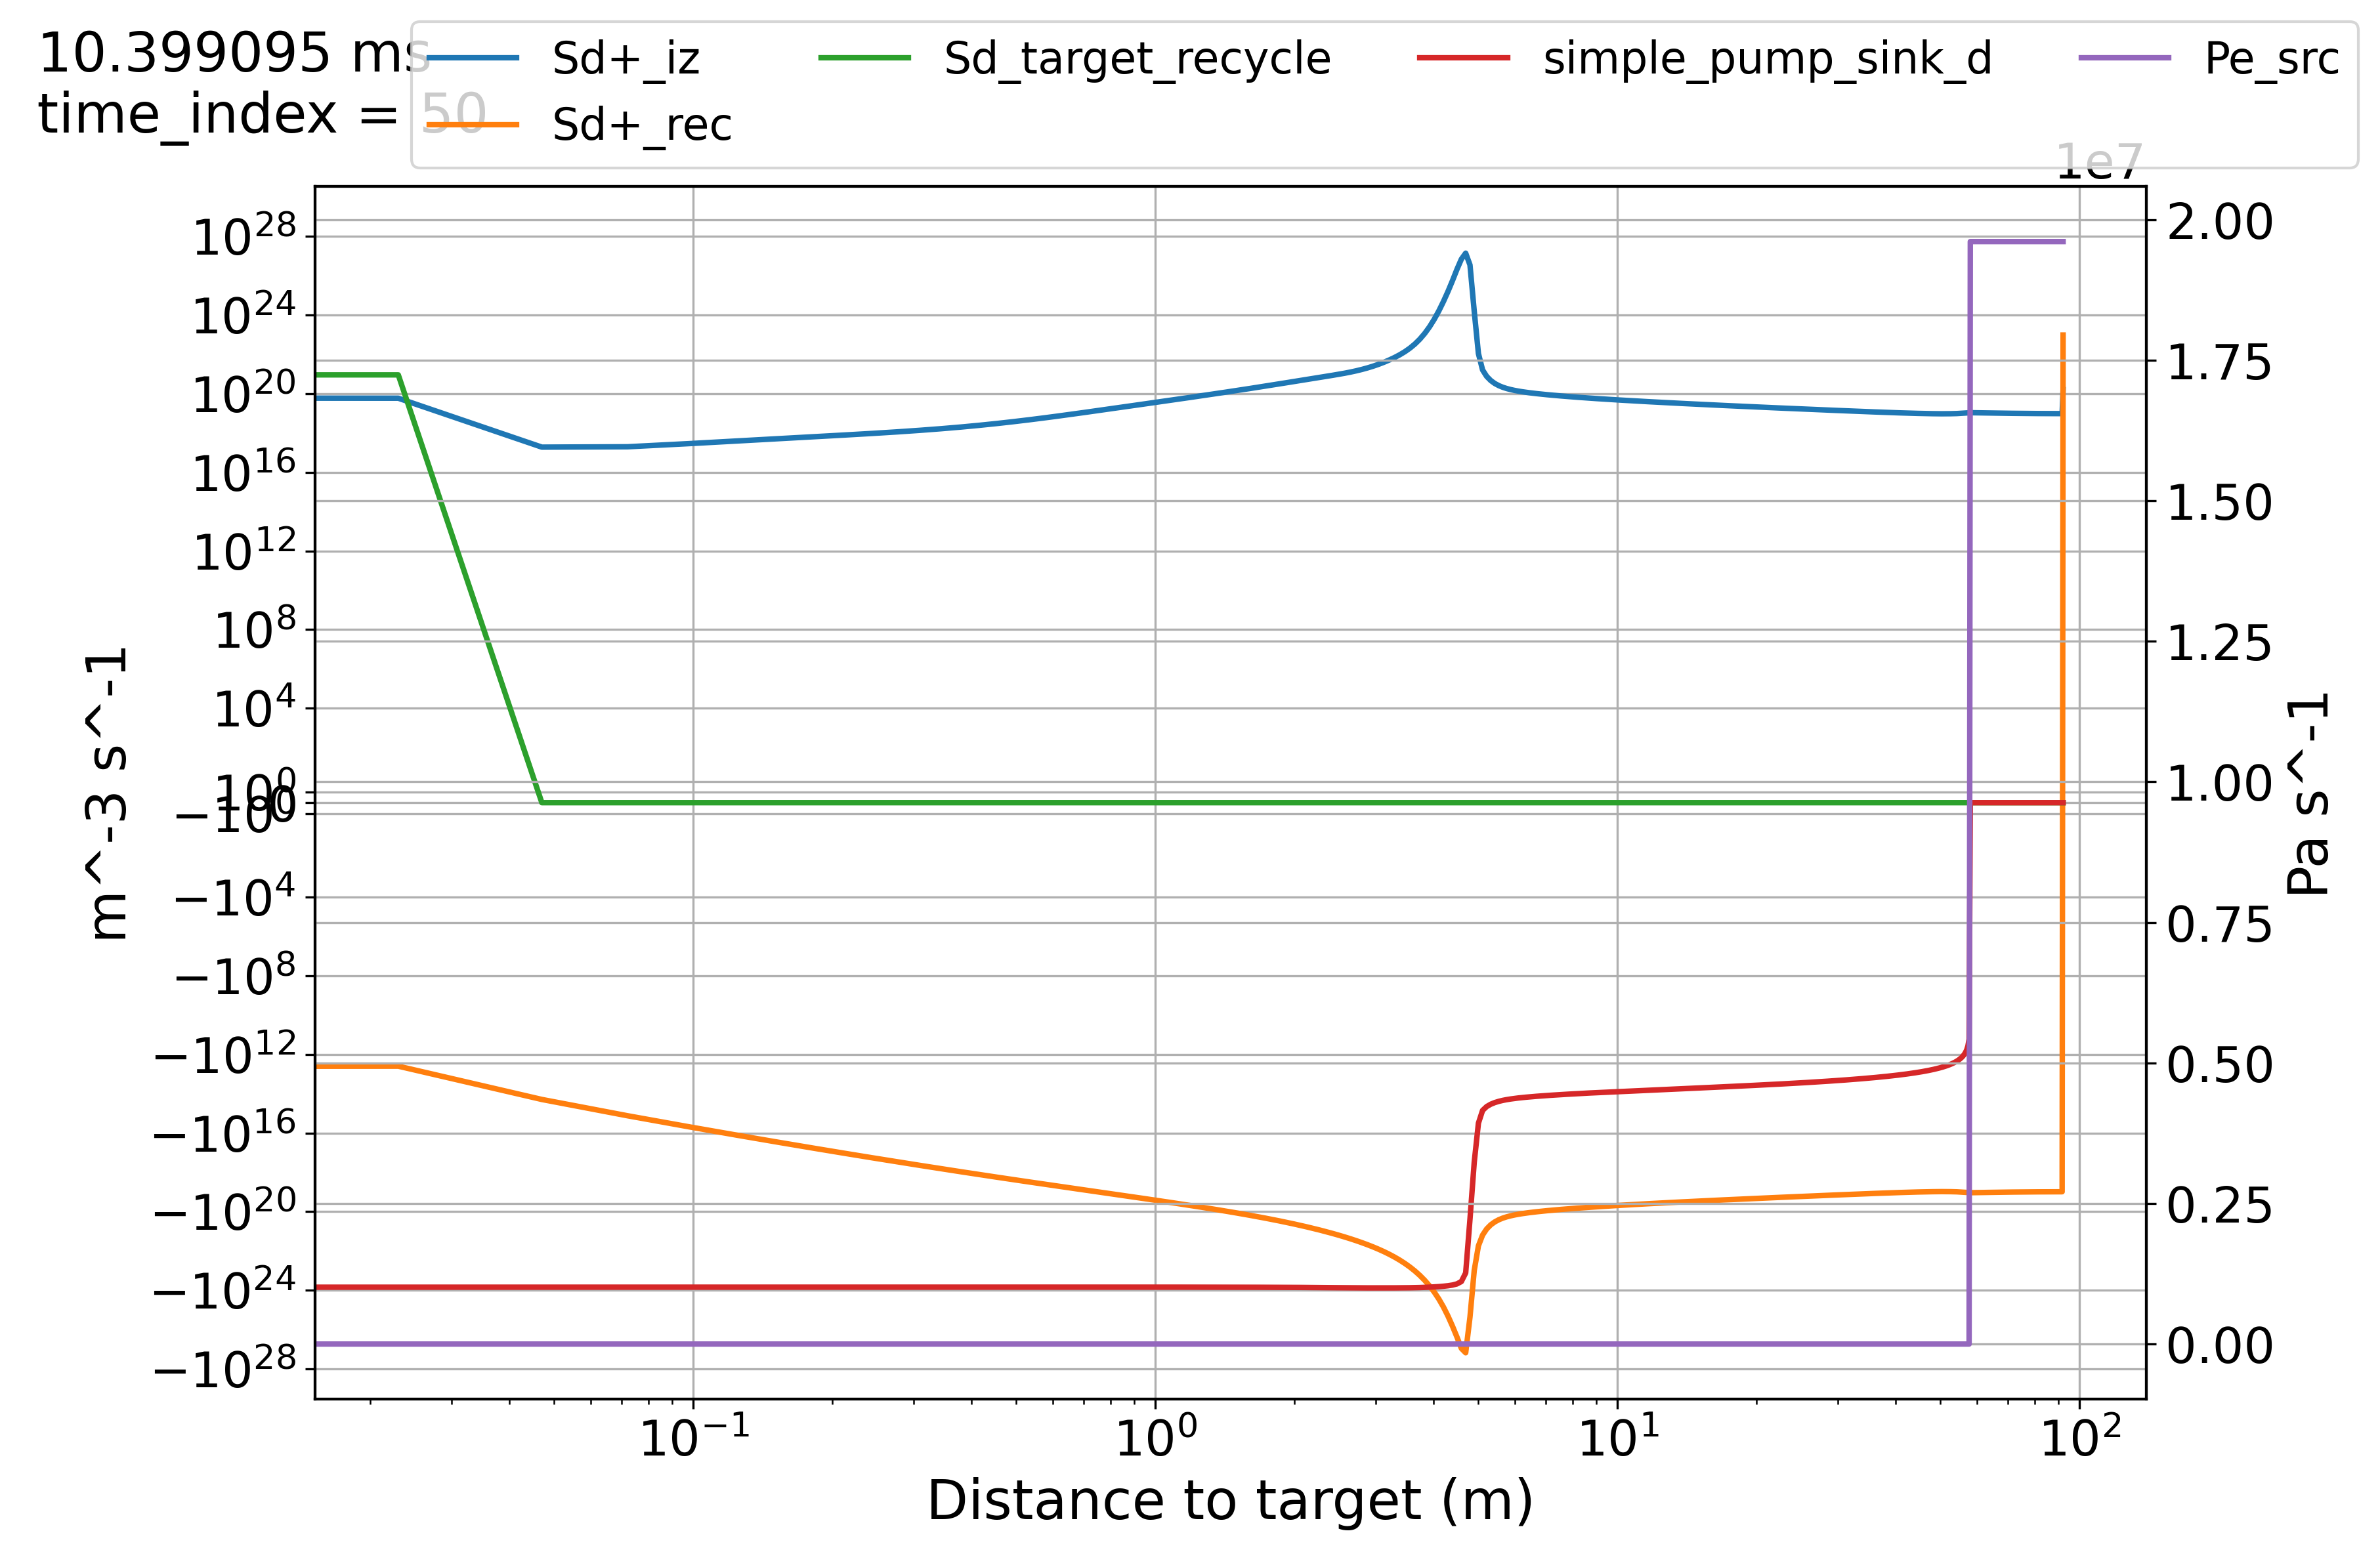

In [14]:

spatial_var(cs['fcx_on'], time = 50, var=['Sd+_iz', 'Sd+_rec','Sd_target_recycle', 'simple_pump_sink_d'], second_axis=['Pe_src'], x_log_scale=True, title='None',
                save=False, save_path=None, focus_target=False, y_scale='symlog', y_scale2='linear',
                first_profile=None, ylim1=None, ylim2=None)

Plotting time series for fcx_off_case_2


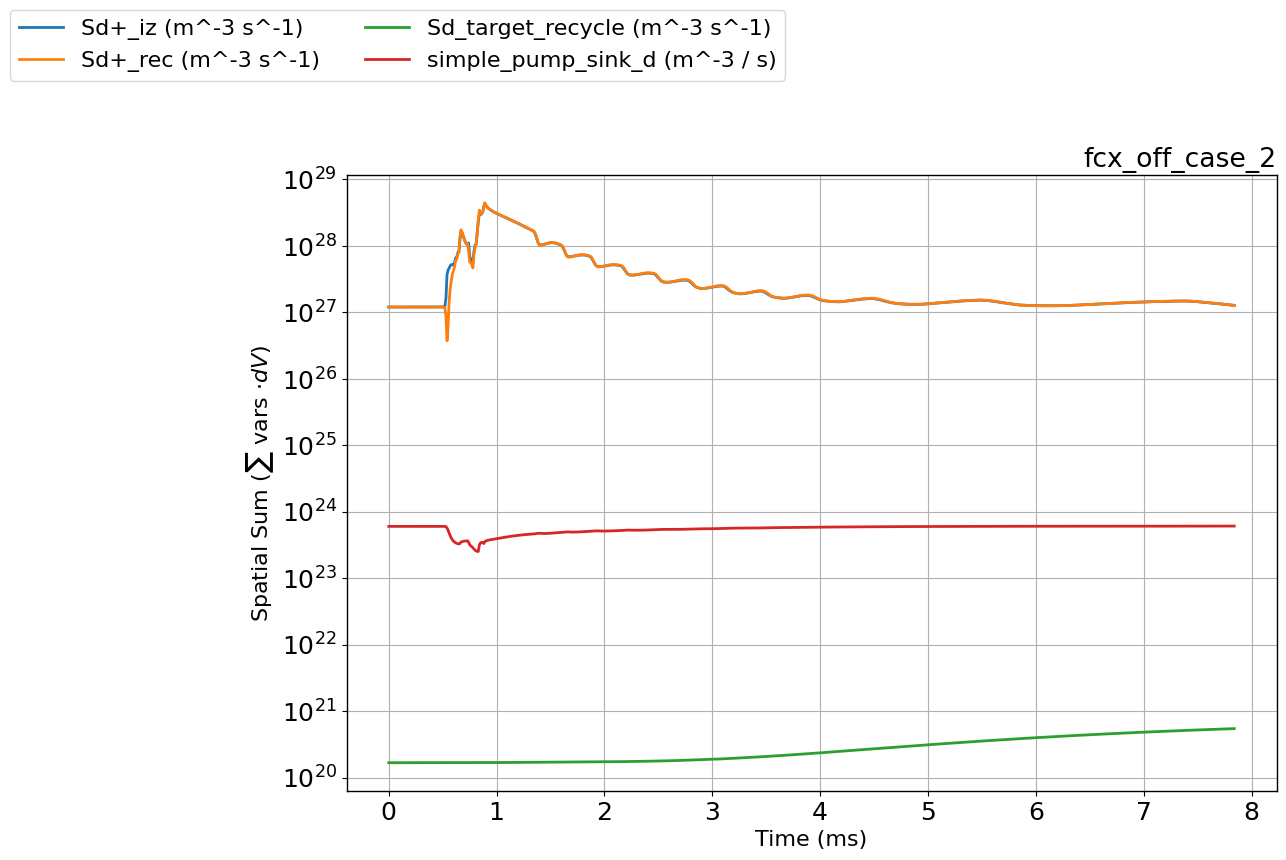

Plotting time series for fcx_on


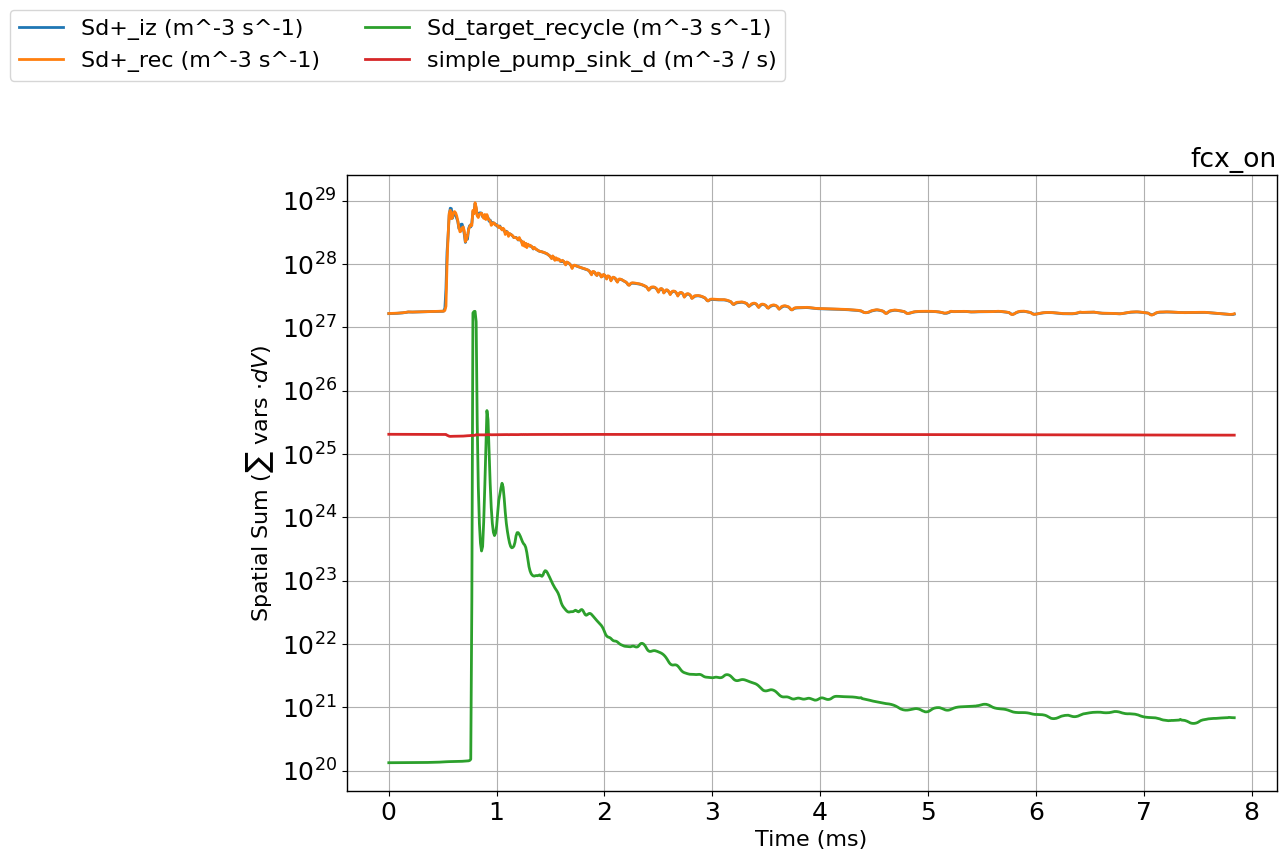

In [ ]:

for name, c in cs.items():
    if name == 'fcx_off':
        continue
    print(f'Plotting time series for {name}')
    plot_spatial_sum_time_series(c, vars = ['Sd+_iz', 'Sd+_rec','Sd_target_recycle', 'simple_pump_sink_d'], 
                                 time_range=(15, 800), mult_dv=True, y_scale='symlog', abs = True, title=name)
# sources_sinks = ['Sd+_iz', 'Sd+_rec','Sd+_sheath','Sd_target_recycle', 'simple_pump_sink_d']

In [ ]:
S_vars = ['Sd+_iz', 'Sd+_rec','Sd_target_recycle', 'simple_pump_sink_d']


spatial_var_mp4(cs['fcx_on'], start_time = 50, end_time=600, var = S_vars,second_axis=[], fps=5,
            mp4_filename=f"fcx_on-sources-sinks.mp4", x_log_scale=True,
            focus_target=False, y_scale='symlog', y_scale2='linear',
            ylim1=None, ylim2=None)

Generating frames...


Creating frames:   5%|▌         | 8/150 [00:07<02:18,  1.03frame/s]

Creating frames: 100%|██████████| 150/150 [02:31<00:00,  1.01s/frame]


Creating MP4...


Writing video: 100%|██████████| 150/150 [00:32<00:00,  4.56frame/s]


Video saved as: fcx_on-sources-sinks.mp4
Total frames processed: 150


In [9]:
S_vars = ['Ne', 'Nd']
S_vars_2 = ['Te', 'Td+']


spatial_var_mp4(cs['fcx_on'], start_time = 50, end_time=600, var = S_vars,second_axis=S_vars_2, fps=5,
            mp4_filename=f"fcx_on-profiles.mp4", x_log_scale=True,
            focus_target=False, y_scale='symlog', y_scale2='linear',
            ylim1=(1e19, 1e25), ylim2=None)


Generating frames...


Creating frames:   1%|▏         | 8/550 [00:07<07:58,  1.13frame/s]

Creating frames: 100%|██████████| 550/550 [09:12<00:00,  1.01s/frame]


Creating MP4...


Writing video: 100%|██████████| 550/550 [04:41<00:00,  1.96frame/s]


Video saved as: fcx_on-profiles.mp4
Total frames processed: 550


# Detachment front movement

In [11]:
import numpy as np
import pandas as pd
import xarray as xr

def front_tracking(ds, more_fronts=False):
    """Optimized front tracking function."""
    ds = ds.copy()
    
    # Extract common data once
    dist = ds["pos"].values
    time_coords = ds["t"].values
    n_times = ds.dims["t"]
    
    # Pre-allocate results dictionary
    results = {"5eV": np.full(n_times, np.nan)}
    
    if more_fronts:
        results.update({
            "Ne_peak": np.full(n_times, np.nan),
            "Rneon": np.full(n_times, np.nan), 
            "iz_peak": np.full(n_times, np.nan),
            "rec_peak": np.full(n_times, np.nan)
        })
    
    def find_crossing_vectorized(data_array, threshold):
        """Vectorized crossing finder for single time slice."""
        diff_signs = np.diff(np.signbit(data_array - threshold))
        crossings = np.where(diff_signs)[0]
        
        if len(crossings) == 0:
            return np.nan
            
        final_crossing = crossings[-1]
        
        # Linear interpolation
        t1, t2 = dist[final_crossing], dist[final_crossing + 1]
        data1, data2 = data_array[final_crossing], data_array[final_crossing + 1]
        
        if data2 == data1:  # Avoid division by zero
            return t1
            
        location = t1 + (threshold - data1) * (t2 - t1) / (data2 - data1)
        return location
    
    # Extract all data arrays once (most important optimization)
    te_data = ds["Te"].values  # Shape: (t, pos)
    
    if more_fronts:
        ne_data = ds["Ne"].values
        rneon_data = ds["Rneon"].values  
        iz_data = ds["Sd+_iz"].values
        rec_data = ds["Sd+_rec"].values
    
    # Process each time step
    for t in range(n_times):
        # 5eV front (always computed)
        results["5eV"][t] = find_crossing_vectorized(te_data[t], 5)
        
        if more_fronts:
            # Peak-based fronts
            ne_slice = ne_data[t]
            results["Ne_peak"][t] = find_crossing_vectorized(ne_slice, ne_slice.max())
            
            rneon_slice = rneon_data[t]
            results["Rneon"][t] = find_crossing_vectorized(rneon_slice, rneon_slice.max())
            
            iz_slice = iz_data[t]
            results["iz_peak"][t] = find_crossing_vectorized(iz_slice, iz_slice.max())
            
            rec_slice = rec_data[t]
            results["rec_peak"][t] = find_crossing_vectorized(rec_slice, rec_slice.max())
    
    # Add results to dataset
    ds["front_pardist_5eV"] = xr.DataArray(
        results["5eV"], 
        dims=["t"], 
        coords={"t": time_coords}
    )
    ds["front_pardist_5eV"].attrs.update({
        "short_name": "5eV front pol. distance from target [m]",
        "units": "m", 
        "origin": "sdtools"
    })
    
    if more_fronts:
        # Add additional front data arrays
        front_arrays = {
            "front_poldist_Rpeak": ("Rneon", "R peak front pol. distance from target [m]"),
            "front_poldist_IZpeak": ("iz_peak", "IZ peak front pol. distance from target [m]"), 
            "front_poldist_Nepeak": ("Ne_peak", "Ne peak front pol. distance from target [m]")
        }
        
        for var_name, (result_key, description) in front_arrays.items():
            ds[var_name] = xr.DataArray(results[result_key], dims=["t"], coords={"t": time_coords})
            ds[var_name].attrs.update({
                "short_name": description,
                "units": "m",
                "origin": "sdtools"
            })
    
    return ds


def front_tracking_fully_vectorized(ds, more_fronts=False):
    """Fully vectorized version - fastest for large datasets."""
    ds = ds.copy()
    
    # Extract data
    dist = ds["pos"].values
    time_coords = ds["t"].values
    
    def find_all_crossings_vectorized(data_3d, thresholds):
        """
        Find crossings for all time steps at once.
        
        Args:
            data_3d: 2D array (time, position)  
            thresholds: 1D array of thresholds for each time step
        """
        # Broadcast threshold to match data shape
        thresh_broadcast = thresholds[:, np.newaxis]
        
        # Find crossings for all time steps
        diff_signs = np.diff(np.signbit(data_3d - thresh_broadcast), axis=1)
        
        results = np.full(len(thresholds), np.nan)
        
        for t in range(len(thresholds)):
            crossings = np.where(diff_signs[t])[0]
            if len(crossings) == 0:
                continue
                
            final_crossing = crossings[-1]
            
            # Linear interpolation
            t1, t2 = dist[final_crossing], dist[final_crossing + 1]
            data1 = data_3d[t, final_crossing]
            data2 = data_3d[t, final_crossing + 1]
            
            if data2 != data1:
                results[t] = t1 + (thresholds[t] - data1) * (t2 - t1) / (data2 - data1)
            else:
                results[t] = t1
                
        return results
    
    # 5eV front
    te_data = ds["Te"].values
    thresholds_5ev = np.full(len(time_coords), 5.0)
    front_5ev = find_all_crossings_vectorized(te_data, thresholds_5ev)
    
    ds["front_pardist_5eV"] = xr.DataArray(
        front_5ev, dims=["t"], coords={"t": time_coords}
    )
    ds["front_pardist_5eV"].attrs.update({
        "short_name": "5eV front pol. distance from target [m]",
        "units": "m",
        "origin": "sdtools"
    })
    
    if more_fronts:
        # Peak-based fronts
        ne_data = ds["Ne"].values
        ne_peaks = np.max(ne_data, axis=1)
        front_ne = find_all_crossings_vectorized(ne_data, ne_peaks)
        
        rneon_data = ds["Rneon"].values
        rneon_peaks = np.max(rneon_data, axis=1)
        front_rneon = find_all_crossings_vectorized(rneon_data, rneon_peaks)
        
        iz_data = ds["Sd+_iz"].values  
        iz_peaks = np.max(iz_data, axis=1)
        front_iz = find_all_crossings_vectorized(iz_data, iz_peaks)
        
        rec_data = ds["Sd+_rec"].values
        rec_peaks = np.max(rec_data, axis=1) 
        front_rec = find_all_crossings_vectorized(rec_data, rec_peaks)
        
        # Add to dataset
        fronts_data = {
            "front_poldist_Rpeak": (front_rneon, "R peak front pol. distance from target [m]"),
            "front_poldist_IZpeak": (front_iz, "IZ peak front pol. distance from target [m]"),
            "front_poldist_Nepeak": (front_ne, "Ne peak front pol. distance from target [m]")
        }
        
        for var_name, (data, description) in fronts_data.items():
            ds[var_name] = xr.DataArray(data, dims=["t"], coords={"t": time_coords})
            ds[var_name].attrs.update({
                "short_name": description, 
                "units": "m",
                "origin": "sdtools"
            })
    
    return ds

In [12]:
for name, c in cs.items():
    print(f'Front tracking for {name}')
    c.ds = front_tracking(c.ds, more_fronts=True)


Front tracking for fcx_off
Front tracking for fcx_off_case_2
Front tracking for fcx_on


Text(0, 0.5, 'Power multiple of initial')

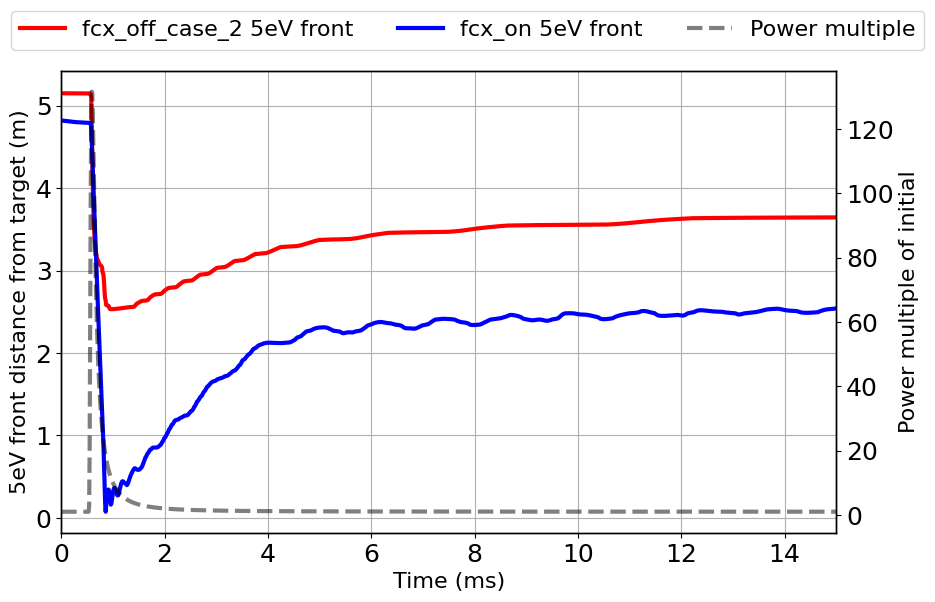

In [13]:

fig,ax = plt.subplots(figsize=(10, 6))
ax2 = ax.twinx()
for name, c in cs.items():

    if name != 'fcx_off':
        if name == 'fcx_off_case_2':
            color = 'red'
        elif name == 'fcx_on':
            color = 'blue'
        detachment = 92 - c.ds['front_pardist_5eV'].values
        # neon_radiation = (ds['Rneon'] * ds['dv']).sum('pos') * 1e-6
        t = (c.ds['t'] - c.ds['t'].values[0])*1e3 - 10  # Adjust time to start from 0

        ax.plot(t, detachment, label=f'{name} 5eV front', linewidth=linewidth,  color = color)


power = cs['fcx_on'].ds['Pe_src'].sum('pos')/cs['fcx_on'].ds['Pe_src'].isel(t=0).sum('pos')  # Convert to MW
ax2.plot(t, power, label='Power multiple', linewidth=linewidth, linestyle='--', color = 'black', alpha = 0.5)

ax.set_xlabel('Time (ms)')
ax.set_ylabel('5eV front distance from target (m)')
ax2.grid(False)
ax.set_xbound(0,15)
fig.legend(ncols = 3)
# ax.set_xscale('log')
ax2.set_ylabel('Power multiple of initial')

# Recombination vs ionisation

AttributeError: 'Text' object has no property 'loc'

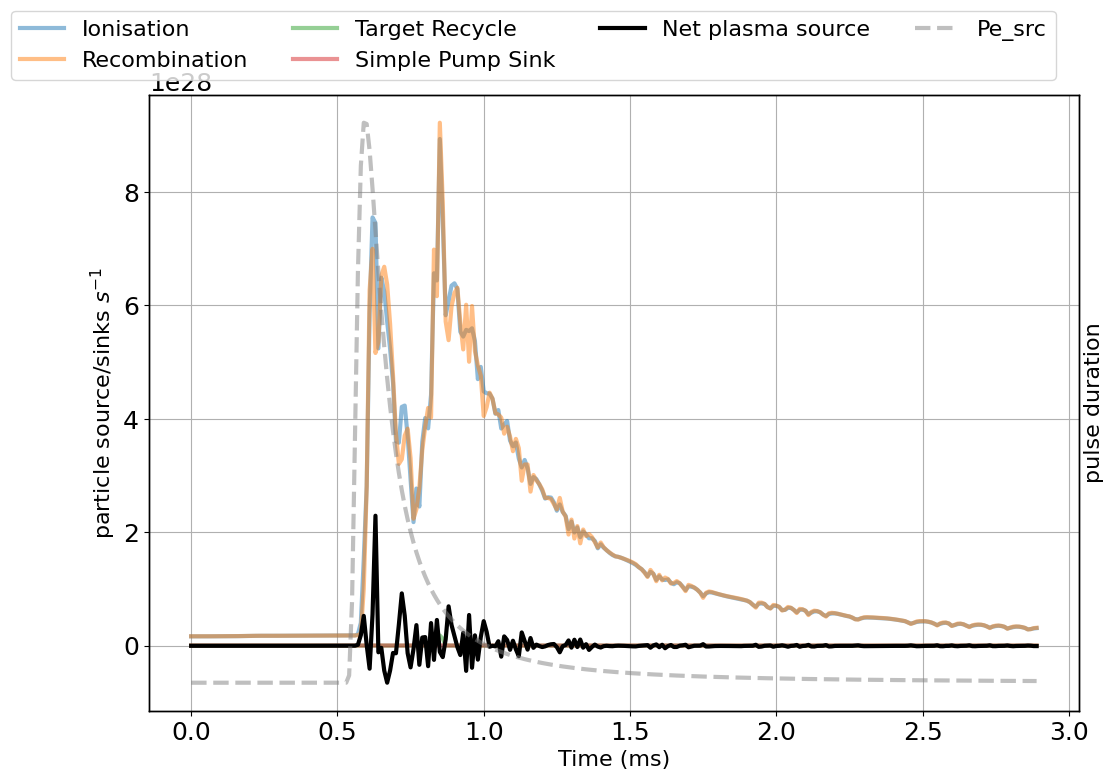

In [ ]:
import matplotlib.pyplot as plt

name = 'fcx_on'
time_range = (10, 300)
ds = cs[name].ds
if time_range is not None:
    ds = ds.isel(t=slice(*time_range))
else:
    ds = ds.isel(t=slice(0, -1))

time = (ds['t'].values - ds['t'].values[0]) *1e3  # normalize time to start at 0

fig, ax = plt.subplots(figsize=(12, 8))
ax2 = ax.twinx()

ionisation = (ds['Sd+_iz'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))).sum(dim='pos')
recombination = (ds['Sd+_rec'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))).sum(dim='pos')
target_recycle = (ds['Sd_target_recycle'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))).sum(dim='pos')
# sheath = (ds['Sd+_sheath'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))).sum(dim='pos')
simple_pump_sink_d = (ds['simple_pump_sink_d'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))).sum(dim='pos')
upstream_source_plasma = (ds['Sd+_src'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))).sum(dim='pos')
neutral_source = (ds['Sd_src'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))).sum(dim='pos')

# Calculate the net ionisation
net_ionisation = ionisation + recombination + target_recycle  + simple_pump_sink_d

ax.plot(time, ionisation, label='Ionisation', linewidth=linewidth, markersize=markersize, alpha=0.5)
ax.plot(time, -1*recombination, label='Recombination', linewidth=linewidth, markersize=markersize, alpha=0.5)
ax.plot(time, target_recycle, label='Target Recycle', linewidth=linewidth, markersize=markersize, alpha=0.5)
# ax.plot(time, -1*sheath, label='Sheath', linewidth=linewidth, markersize=markersize, alpha=0.5)
ax.plot(time, -1*simple_pump_sink_d, label='Simple Pump Sink', linewidth=linewidth, markersize=markersize, alpha=0.5)
# Plot the net ionisation
ax.plot(time, net_ionisation, label='Net plasma source', linewidth=linewidth, markersize=markersize, linestyle='-', color='black')
ax2.plot(time, ds['Pe_src'].isel(pos=slice(2, -2)).sum(dim='pos') - ds['Pe_src'].isel(pos=slice(2, -2)).sum(dim='pos')[3], label='Pe_src', color='grey', linewidth=linewidth, markersize=markersize, alpha=0.5, linestyle='--')

# ax.set_yscale('symlog')
ax.set_xlabel('Time (ms)')
ax.set_ylabel(r'particle source/sinks $s^{-1}$')
ax2.grid(False)
ax2.set_ylabel(r'pulse duration')
ax2.set_yticks([])
# ax.set_xbound(0.5, 0.8)
fig.legend(ncols=4, loc='upper left')
ax.set_title(f'{name}', loc = 'right')
print(np.max(net_ionisation.values))

print('time taken to ionise neutral cloud = ',  (2.579862250025524e+24 / np.max(net_ionisation.values))*1e3, 'ms')
    

# Burn through animations

In [ ]:
var = ['Te', 'Td+']
second_axis = ['Ne', 'Nd']


spatial_var_mp4(cs['fcx_on'], start_time = 0, end_time = 10, var=var, second_axis=second_axis, fps=5,
                    mp4_filename="new_fcx_on.mp4", x_log_scale=True,
                    focus_target=False, y_scale='log', y_scale2='log',
                    ylim1=None, ylim2=None)

: 